In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import t as student_t
from scipy.stats import norm
import matplotlib.patches as mpatches


In [40]:
# ----------------------------
# 1.1 and 1.2: Simulation
# ----------------------------
def simulate_state_space(n=100, a=0.9, b=1.0, sigma1=1.0, sigma2=1.0, x0=5.0, seed=None, student_df=None):
    rng = np.random.default_rng(seed)
    x = np.zeros(n + 1)
    y = np.zeros(n)

    x[0] = x0
    if student_df is None:
        e1 = rng.normal(0, sigma1, size=n)
    else:
        e1 = rng.standard_t(student_df, size=n) * sigma1

    e2 = rng.normal(0, sigma2, size=n)

    for t in range(1, n + 1):
        x[t] = a * x[t - 1] + b + e1[t - 1]
        y[t - 1] = x[t] + e2[t - 1]

    return x, y

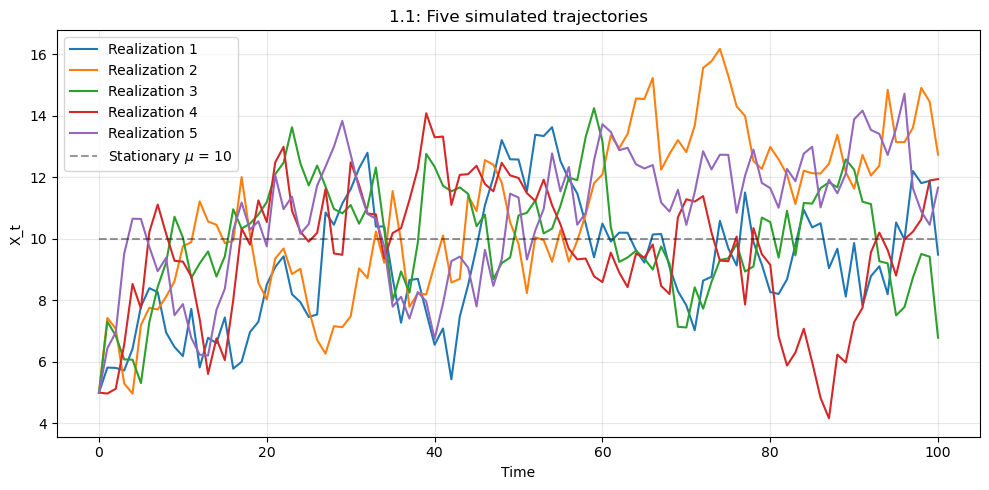

In [41]:
# ----------------------------
# 1.1 Plot 5 trajectories
# ----------------------------
n = 100
a, b, sigma1, sigma2, x0 = 0.9, 1.0, 1.0, 1.0, 5.0

fig, ax = plt.subplots(figsize=(10, 5))
for i in range(5):
    x, _ = simulate_state_space(n=n, a=a, b=b, sigma1=sigma1, sigma2=sigma2, x0=x0, seed=200 + i)
    ax.plot(np.arange(n + 1), x, label=f"Realization {i+1}")
stat_line = b/(1 - a)
ax.plot(np.arange(n + 1), stat_line * np.ones(n + 1), label=f"Stationary $\\mu$ = {stat_line:.0f}", linestyle="--", color="black", alpha=0.4)
ax.set_title("1.1: Five simulated trajectories")
ax.set_xlabel("Time")
ax.set_ylabel("X_t")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

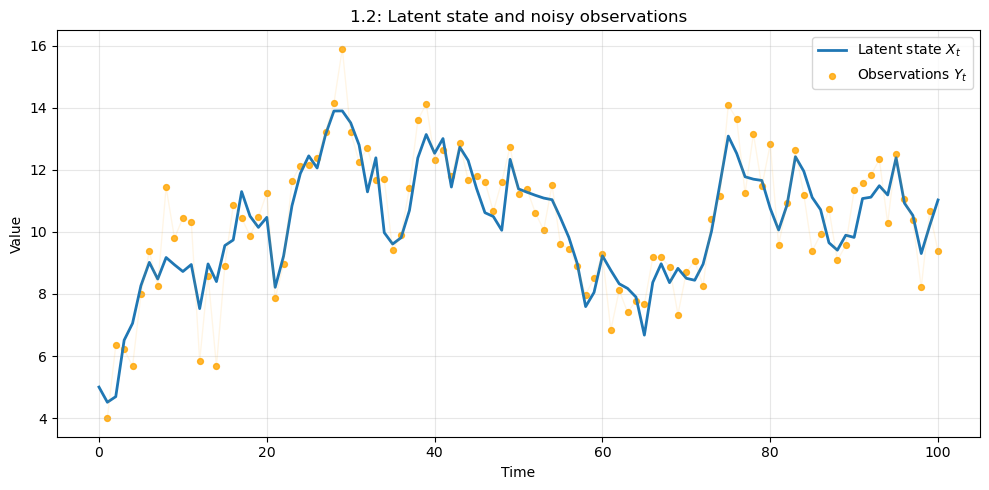

In [42]:
# ----------------------------
# 1.2 One latent state + noisy observations
# ----------------------------
x, y = simulate_state_space(n=n, a=a, b=b, sigma1=sigma1, sigma2=sigma2, x0=x0, seed=123)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.arange(n + 1), x, label="Latent state $X_t$", linewidth=2)

ax.scatter(np.arange(1, n + 1), y, label="Observations $Y_t$", s=18, alpha=0.8,color ="orange")
ax.plot(np.arange(1, n + 1), y, linewidth=1, alpha=0.1,color ="orange")

ax.set_title("1.2: Latent state and noisy observations")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


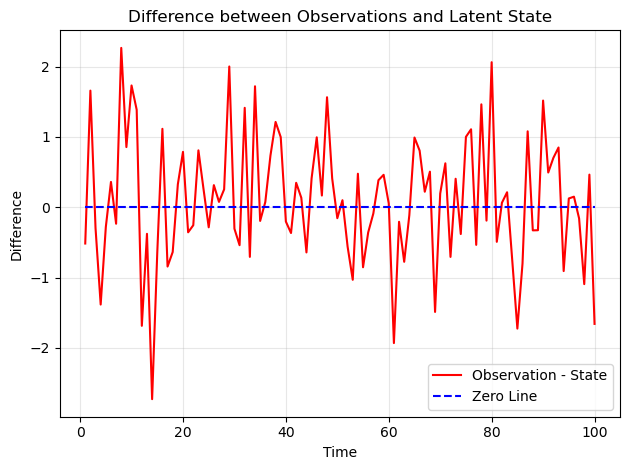

In [43]:
## plot y - x differences in a normal distribution

# n = 100
# x, y = simulate_state_space(n=n, a=a, b=b, sigma1=sigma1, sigma2=sigma2, x0=x0, seed=123)

# plt.figure(figsize=(10, 5))
# difs = y - x[1:]
# plt.hist(difs, bins=30, density=True, alpha=0.6, color="red", label="Differences")
# mu, std = norm.fit(difs)


# xmin, xmax = plt.xlim()
# x_fit = np.linspace(xmin, xmax, 100)
# p_fit = norm.pdf(x_fit, mu, std)
# plt.plot(x_fit, p_fit, color="blue", label=f"Fit: N({mu:.2f}, {std:.2f}^2)")
# plt.title("Distribution of Differences (Observation - State)")
# plt.xlabel("Difference")
# plt.ylabel("Density")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()
plt.plot(np.arange(1, n + 1), y - x[1:], label="Observation - State", color="red")
plt.plot(np.arange(1, n + 1), np.zeros(n), label="Zero Line", color="blue", linestyle="--")
plt.title("Difference between Observations and Latent State")
plt.xlabel("Time")
plt.ylabel("Difference")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
# ----------------------------
# 1.3: Scalar Kalman filter
# ----------------------------
def kalman_filter_scalar(y, theta, R=1.0, x0=5.0, P0=10.0):
    a, b, sigma1 = theta
    n = len(y)

    x_pred = np.zeros(n)
    P_pred = np.zeros(n)
    x_filt = np.zeros(n)
    P_filt = np.zeros(n)
    innov = np.zeros(n)
    innov_var = np.zeros(n)

    x_prev = x0
    P_prev = P0

    for t in range(n):
        x_pred[t] = a * x_prev + b
        P_pred[t] = a**2 * P_prev + sigma1**2

        innov[t] = y[t] - x_pred[t]
        innov_var[t] = P_pred[t] + R
        K = P_pred[t] / innov_var[t]

        x_filt[t] = x_pred[t] + K * innov[t]
        P_filt[t] = (1 - K) * P_pred[t]

        x_prev, P_prev = x_filt[t], P_filt[t]

    return {
        "x_pred": x_pred,
        "P_pred": P_pred,
        "x_filt": x_filt,
        "P_filt": P_filt,
        "innovation": innov,
        "innovation_var": innov_var,
    }

def neg_loglik(theta, y, R=1.0, x0=5.0, P0=10.0):
    a, b, sigma1 = theta
    if sigma1 <= 0 or not (-5 <= a <= 5):
        return np.inf
    out = kalman_filter_scalar(y, theta, R=R, x0=x0, P0=P0)
    v = out["innovation_var"]
    e = out["innovation"]
    return 0.5 * np.sum(np.log(2 * np.pi * v) + (e**2) / v)

def estimate_params(y, start=(0.5, 0.5, 1.0), R=1.0, x0=5.0, P0=10.0):
    bounds = [(-5, 5), (-5, 5), (1e-6, 10)]
    res = minimize(
        neg_loglik,
        x0=np.array(start, dtype=float),
        args=(y, R, x0, P0),
        method="L-BFGS-B",
        bounds=bounds,
    )
    return res

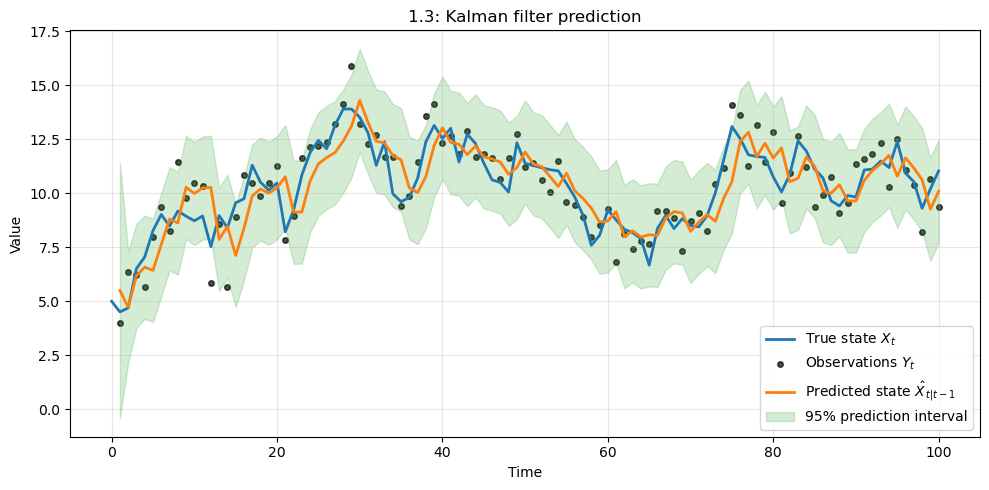

Number of observations outside 95% observation prediction interval: 2


In [45]:
# ----------------------------
# 1.3 Kalman filter on one realization
# ----------------------------

# x, y = simulate_state_space(n=n, a=a, b=b, sigma1=sigma1, sigma2=sigma2, x0=x0)

kf = kalman_filter_scalar(y, theta=(a, b, sigma1), R=sigma2**2, x0=x0, P0=10.0)

t = np.arange(1, n + 1)
ci_low = kf["x_pred"] - 1.96 * np.sqrt(kf["P_pred"])
ci_high = kf["x_pred"] + 1.96 * np.sqrt(kf["P_pred"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.arange(n + 1), x, label="True state $X_t$", linewidth=2)
ax.scatter(t, y, label="Observations $Y_t$", s=16, alpha=0.7,color="black")
ax.plot(t, kf["x_pred"], label="Predicted state $\\hat X_{t|t-1}$", linewidth=2)
ax.fill_between(t, ci_low, ci_high, color="C2", alpha=0.2, label="95% prediction interval")
ax.set_title("1.3: Kalman filter prediction")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 2. Observation Prediction Interval (For the numerical check)
# Innovation variance S_t = P_t|t-1 + R
S_pred = kf["P_pred"] + sigma2**2  

# 3. Checking observations outside limits using the OBSERVATION interval (S_pred)
outside_limits = np.abs(y - kf["x_pred"]) > 1.96 * np.sqrt(S_pred)

print(f"Number of observations outside 95% observation prediction interval: {np.sum(outside_limits)}")

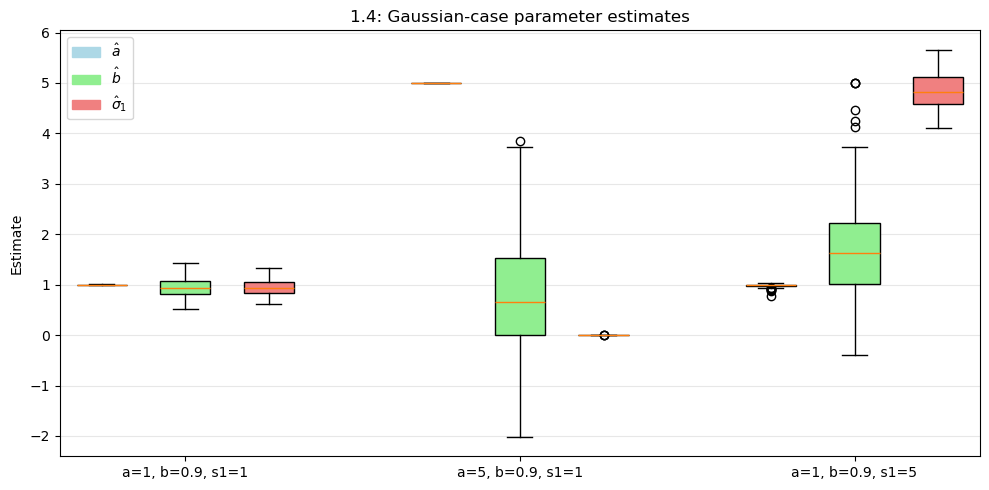

a_hat                         b_hat                      \
                      mean       std    median      mean       std    median   
case                                                                           
a=1, b=0.9, s1=1  0.999718  0.003910  0.999821  0.943040  0.201614  0.932321   
a=1, b=0.9, s1=5  0.977787  0.034264  0.986307  1.778105  1.109655  1.627248   
a=5, b=0.9, s1=1  5.000000  0.000000  5.000000  0.748027  1.154739  0.660376   

                 sigma1_hat                      
                       mean       std    median  
case                                             
a=1, b=0.9, s1=1   0.940661  0.142352  0.939407  
a=1, b=0.9, s1=5   4.856032  0.357993  4.826747  
a=5, b=0.9, s1=1   0.000006  0.000040  0.000001

In [46]:
# ----------------------------
# 1.4 Monte Carlo estimation
# ----------------------------
def monte_carlo_estimation(n_rep=100, n=100, a=1.0, b=0.9, sigma1=1.0, sigma2=1.0, x0=5.0, seed=999):
    rng = np.random.default_rng(seed)
    est = []
    for r in range(n_rep):
        x_sim, y_sim = simulate_state_space(
            n=n, a=a, b=b, sigma1=sigma1, sigma2=sigma2, x0=x0, seed=int(rng.integers(1e9))
        )
        res = estimate_params(y_sim, start=(0.8, 0.5, 1.0), R=sigma2**2, x0=x0, P0=10.0)
        est.append([res.x[0], res.x[1], res.x[2], res.fun, res.success])
    return pd.DataFrame(est, columns=["a_hat", "b_hat", "sigma1_hat", "nll", "success"])

gauss_case_1 = monte_carlo_estimation(a=1.0, b=0.9, sigma1=1.0, sigma2=1.0, x0=5.0, seed=1)
gauss_case_2 = monte_carlo_estimation(a=5.0, b=0.9, sigma1=1.0, sigma2=1.0, x0=5.0, seed=2)
gauss_case_3 = monte_carlo_estimation(a=1.0, b=0.9, sigma1=5.0, sigma2=1.0, x0=5.0, seed=3)

def boxplot_estimates(df_list, labels, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    data = []
    positions = []
    
    # Define colors and labels for the 3 parameters
    colors = ['lightblue', 'lightgreen', 'lightcoral']
    param_labels = ['$\\hat{a}$', '$\\hat{b}$', '$\\hat{\\sigma}_1$']
    box_colors = []
    
    for i, df_ in enumerate(df_list):
        for j, col in enumerate(["a_hat", "b_hat", "sigma1_hat"]):
            data.append(df_[col].values)
            positions.append(i * 4 + j + 1)
            box_colors.append(colors[j]) # Keep track of which color goes to which box
            
    # patch_artist=True allows us to fill the boxes with color
    bplot = ax.boxplot(data, positions=positions, widths=0.6, showfliers=True, patch_artist=True)
    
    # Apply the colors to the boxes
    for patch, color in zip(bplot['boxes'], box_colors):
        patch.set_facecolor(color)
        
    # Set the x-axis labels
    ax.set_xticks([2, 6, 10])
    ax.set_xticklabels(labels)
    ax.set_ylabel("Estimate")
    ax.set_title(title)
    
    # Create a custom legend
    legend_handles = [mpatches.Patch(color=colors[i], label=param_labels[i]) for i in range(3)]
    ax.legend(handles=legend_handles, loc='upper left')
    
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


boxplot_estimates(
    [gauss_case_1, gauss_case_2, gauss_case_3],
    ["a=1, b=0.9, s1=1", "a=5, b=0.9, s1=1", "a=1, b=0.9, s1=5"],
    "1.4: Gaussian-case parameter estimates"
)

summary = pd.concat(
    [
        gauss_case_1.assign(case="a=1, b=0.9, s1=1"),
        gauss_case_2.assign(case="a=5, b=0.9, s1=1"),
        gauss_case_3.assign(case="a=1, b=0.9, s1=5"),
    ]
)

summary.groupby("case")[["a_hat", "b_hat", "sigma1_hat"]].agg(["mean", "std", "median"])


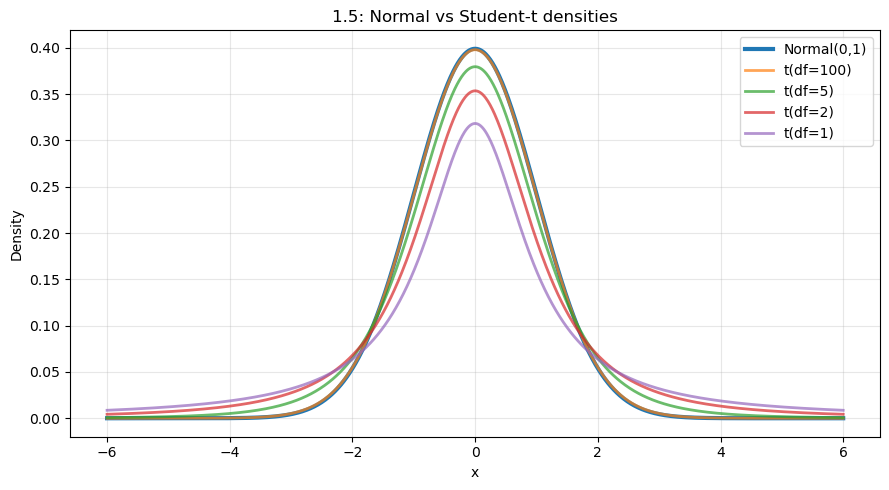

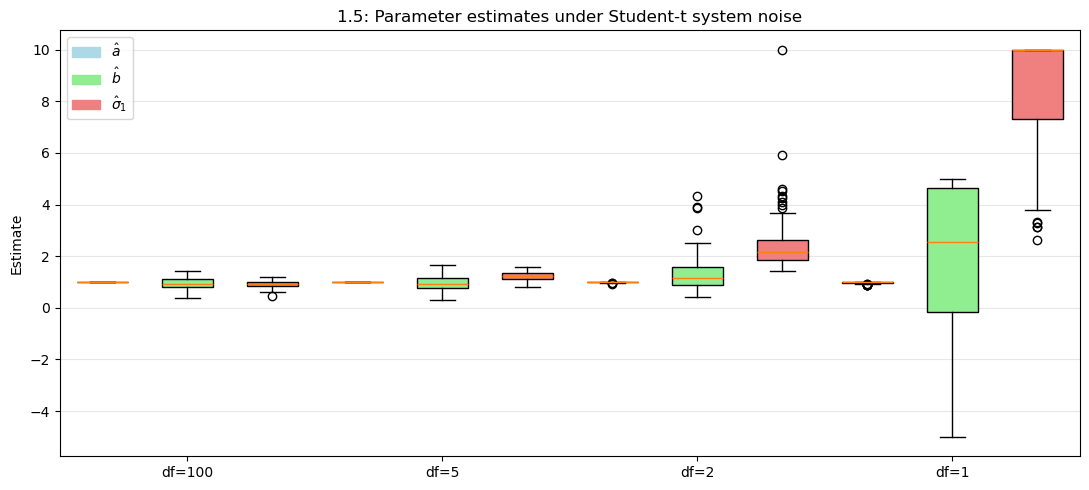

In [47]:
# ----------------------------
# 1.5 Student-t noise robustness
# ----------------------------
def t_density_plot(dfs=(100, 5, 2, 1), xlim=(-6, 6)):
    xs = np.linspace(xlim[0], xlim[1], 1000)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(xs, norm.pdf(xs, 0, 1), label="Normal(0,1)", linewidth=3)
    for dfv in dfs:
        ax.plot(xs, student_t.pdf(xs, dfv), label=f"t(df={dfv})", linewidth=2, alpha=0.7)
    ax.set_title("1.5: Normal vs Student-t densities")
    ax.set_xlabel("x")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

t_density_plot()

def monte_carlo_t(n_rep=100, n=100, a=1.0, b=0.9, sigma1=1.0, sigma2=1.0, x0=5.0, df=5, seed=1234):
    rng = np.random.default_rng(seed)
    est = []
    for r in range(n_rep):
        x_sim, y_sim = simulate_state_space(
            n=n, a=a, b=b, sigma1=sigma1, sigma2=sigma2, x0=x0,
            seed=int(rng.integers(1e9)), student_df=df
        )
        res = estimate_params(y_sim, start=(0.8, 0.5, 1.0), R=sigma2**2, x0=x0, P0=10.0)
        est.append([res.x[0], res.x[1], res.x[2], res.fun, res.success])
    return pd.DataFrame(est, columns=["a_hat", "b_hat", "sigma1_hat", "nll", "success"])

t_cases = {
    100: monte_carlo_t(df=100, seed=10),
    5: monte_carlo_t(df=5, seed=11),
    2: monte_carlo_t(df=2, seed=12),
    1: monte_carlo_t(df=1, seed=13),
}

fig, ax = plt.subplots(figsize=(11, 5))
data = []
positions = []
labels = []
pos = 1

for dfv, res in t_cases.items():
    for col in ["a_hat", "b_hat", "sigma1_hat"]:
        data.append(res[col].values)
        positions.append(pos)
        pos += 1
    labels.extend([f"t({dfv})", "", ""])
bplot = ax.boxplot(data, positions=positions, widths=0.6, showfliers=True, patch_artist=True)


colors = ['lightblue', 'lightgreen', 'lightcoral']
param_labels = ['$\\hat{a}$', '$\\hat{b}$', '$\\hat{\\sigma}_1$']
box_colors = colors * len(t_cases) 

for patch, color in zip(bplot['boxes'], box_colors):
    patch.set_facecolor(color)
legend_handles = [mpatches.Patch(color=colors[i], label=param_labels[i]) for i in range(3)]
ax.legend(handles=legend_handles, loc='upper left')
ax.set_xticks([2, 5, 8, 11])
ax.set_xticklabels(["df=100", "df=5", "df=2", "df=1"])
ax.set_ylabel("Estimate")
ax.set_title("1.5: Parameter estimates under Student-t system noise")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Save summaries
out = pd.concat(
    [summary, pd.concat([v.assign(df=k) for k, v in t_cases.items()], ignore_index=True)],
    ignore_index=True
)
out.to_csv("part1_estimation_summary.csv", index=False)

In [ ]:
def estimate_params_2(y, start=(0.5, 0.5, 1.0), R=1.0, x0=5.0, P0=200.0):
    bounds = [(-5, 5), (-5, 5), (1e-6, 10)]
    res = minimize(
        neg_loglik,
        x0=np.array(start, dtype=float),
        args=(y, R, x0, P0),
        method="L-BFGS-B",
        bounds=bounds,
    )
    return res

Average of sigma1_hat for df=1 with new bounds: 34.1506


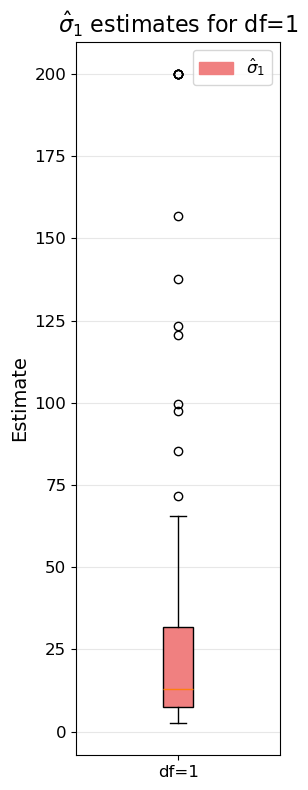

In [50]:
# ----------------------------
# 1.6 Re-estimation for df=1 with new bounds
# ----------------------------
def estimate_params_new_bounds(y, start=(0.5, 0.5, 1.0), R=1.0, x0=5.0, P0=10.0):
    bounds = [(-5, 5), (-5, 5), (1e-6, 200)]  # New bounds for sigma1
    res = minimize(
        neg_loglik,
        x0=np.array(start, dtype=float),
        args=(y, R, x0, P0),
        method="L-BFGS-B",
        bounds=bounds,
    )
    return res

def monte_carlo_t_new_bounds(n_rep=100, n=100, a=1.0, b=0.9, sigma1=1.0, sigma2=1.0, x0=5.0, df=5, seed=1234):
    rng = np.random.default_rng(seed)
    est = []
    for r in range(n_rep):
        x_sim, y_sim = simulate_state_space(
            n=n, a=a, b=b, sigma1=sigma1, sigma2=sigma2, x0=x0,
            seed=int(rng.integers(1e9)), student_df=df
        )
        # Use the new estimation function
        res = estimate_params_new_bounds(y_sim, start=(0.8, 0.5, 1.0), R=sigma2**2, x0=x0, P0=10.0)
        est.append([res.x[0], res.x[1], res.x[2], res.fun, res.success])
    return pd.DataFrame(est, columns=["a_hat", "b_hat", "sigma1_hat", "nll", "success"])

# Rerun for df=1
t_case_df1_new_bounds = monte_carlo_t_new_bounds(df=1, seed=13)

# Calculate and print the average of sigma1_hat
avg_sigma1_hat = t_case_df1_new_bounds["sigma1_hat"].mean()
print(f"Average of sigma1_hat for df=1 with new bounds: {avg_sigma1_hat:.4f}")

# Create the boxplot
fig, ax = plt.subplots(figsize=(3, 8))
bplot = ax.boxplot(t_case_df1_new_bounds["sigma1_hat"], showfliers=True, patch_artist=True)
bplot['boxes'][0].set_facecolor('lightcoral')

ax.set_xticklabels(["df=1"], fontsize=12)
ax.set_ylabel("Estimate", fontsize=14)
ax.set_title("$\\hat{\\sigma}_1$ estimates for df=1", fontsize=16)
legend_handles = [mpatches.Patch(color='lightcoral', label='$\\hat{\\sigma}_1$')]
ax.legend(handles=legend_handles, loc='upper right', fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
